In [1]:
from MILO_setup1 import *

# Apply MILO on low-purity sWGS samples

## Prediction of low-purity samples by MSIsensor2

In [2]:
msisensor2_df_merged_low_purity = pd.read_csv ("./Data/msisensor2_df_merged_low_purity.csv", 
                                               index_col = 0)
msisensor2_df_merged_low_purity.shape

(174, 18)

In [3]:
def plot_confusion_matrix(cf_matrix, f=None, target_names=None, title = None):

    group_names = ['TN', 'FP', 'FN', 'TP']
    group_counts = ["{0:.0f}".format(value) for value in 
                    cf_matrix.flatten()]
    group_percentages = ["{0:.2%}".format(value) for value in 
                         cf_matrix.flatten()/np.sum(cf_matrix)]
    labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in 
              zip(group_names,
                  group_counts,
                  group_percentages)
             ]
    labels = np.asarray(labels).reshape(2, 2)

    plt.figure(figsize = (3.5, 2))
    sns.heatmap(cf_matrix, annot=labels, fmt='', cmap='Blues',  annot_kws={"size": 11})
    if target_names:
        tick_marks = range(len(target_names))
        plt.xticks(tick_marks, target_names,ha='right')
        plt.yticks(tick_marks, target_names,ha='center')
    if title:
        plt.title (title,fontsize = 12)

    precision = cf_matrix[1, 1] / sum(cf_matrix[:, 1])
    recall    = cf_matrix[1, 1] / sum(cf_matrix[1,:])
    accuracy  = np.trace(cf_matrix) / float(np.sum(cf_matrix))
    f1_score  = 2 * precision * recall / (precision + recall)
    
    stats_text = "Precision={:0.2f}; Recall={:0.2f};\nAccuracy={:0.2f}; F1 Score={:0.2f}".format(
        precision, recall, accuracy, f1_score)
    
    plt.xlabel('Predicted label\n\n{}'.format(stats_text), fontsize = 11)
    plt.ylabel("True Label",fontsize = 11)
    if f:
        plt.savefig(f, bbox_inches = "tight", dpi = 300)
    plt.show()

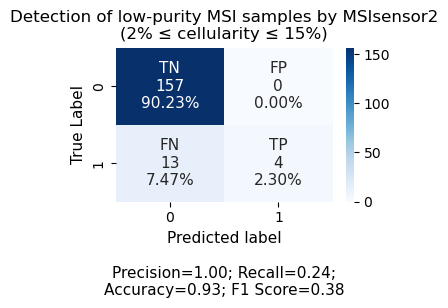

In [4]:
y_test_true = msisensor2_df_merged_low_purity.loc[:,
                                     'MSI_status'].to_numpy()
y_test_predict = msisensor2_df_merged_low_purity['MSIsensor2_predict']

cm = confusion_matrix(y_test_true, y_test_predict)
plot_confusion_matrix(cm, title = "Detection of low-purity MSI samples by MSIsensor2\n(2% ≤ cellularity ≤ 15%)", 
                     f = "./Figures/MILO_Fig5h.pdf")

## Prediction of low-purity samples by MILO

In [5]:
epicc_lowpass_df_t = pd.read_csv ("./Data/EPICC_all_low_pass_data.csv", index_col= 0)
MILO_test_data = epicc_lowpass_df_t.loc[msisensor2_df_merged_low_purity['Sample'],:].iloc[:,96:179]

In [6]:
## output 83-channel profiles to a local file and prepare for MILO input:
MILO_test_data.to_csv("./Data/MILO_test_data.csv")

df_milo = MILO("./Data/MILO_test_data.csv", "FF")
## Low-confidence results:
sum(df_milo['MILO_prediction'] == 'Maybe')

0

In [7]:
## make a numerical classification (0 or 1) based on the categrical prediction by MILO.
df_milo['MILO_prediction_num'] = 0
df_milo.loc[df_milo['MILO_prediction'] == 'Yes', 'MILO_prediction_num'] = 1

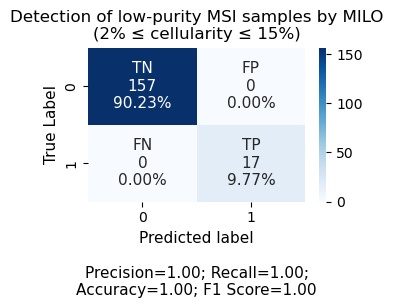

In [8]:
## confusion matrix
y_test_predict = df_milo['MILO_prediction_num'].to_numpy()

y_test_true = epicc_lowpass_df_t.loc[msisensor2_df_merged_low_purity['Sample'], 
                                     'MSI_status'].to_numpy()

cm = confusion_matrix(y_test_true, y_test_predict)
plot_confusion_matrix(cm,
                title = "Detection of low-purity MSI samples by MILO\n(2% ≤ cellularity ≤ 15%)", 
                     f = "./Figures/MILO_Fig5g.pdf")

# Apply MILO on IBD samples (FFPE+sWGS)

## MILO prediction

In [9]:
# Initial MILO prediction without error correction
df1 = MILO("./Data/IBD_Patient_2429_83c_indels.csv", 'FFPE')

In [10]:
## Read our input data
ibd_matrix = pd.read_csv ("./Data/IBD_Patient_2429_83c_indels.csv", index_col = 0)
ibd_matrix_norm = (ibd_matrix.T / ibd_matrix.T.sum()).T.copy()

## from our initial MILO test
sample_with_extrame_low_probMSI = df1.sort_values('Prob(MSI)').index[0]

noise_profile_from_cohort = ibd_matrix_norm.loc[sample_with_extrame_low_probMSI, 
                                                :][:83].astype("float64").to_numpy()
ibd_matrix.shape

(17, 83)

In [11]:
rename_samples = {'2429-L1A_S12' : 'L_TP3_A1', 
                  '2429-L1B_S13' : 'L_TP3_A2', 
                  '2429-L2A_S14' : 'L_TP3_C1',
                  '2429-L2B_S15' : 'L_TP3_C2', 
                  '2429-L2C_S16' : 'L_TP3_C3', 
                  'A6_2429-TP2-P3C-B' : 'L_TP2_C2', 
                  'B12_2429-TP2-P3A-B': 'L_TP2_A2', 
                  'F3_2429-TP2-P3B-A' : 'L_TP2_B2', 
                  'XB6_2429-TP2-P3C-A' : 'L_TP2_C1',
                  'XC5_2429-TPF-2429-C1A' : 'C_TP3_B1', 
                  'XC6_2429-TPF-2429-C1B' : 'C_TP3_B2',
                  'XC7_2429-TPF-2429-C1C' : 'C_TP3_B3', 
                  'XF1_2429-TP2-P3B-B' : 'L_TP2_B1',
                  'XG8_2429-TP1-P3D-A' : 'L_TP1_A',
                  'ZA7_2429-TP2-P3C-C' : 'L_TP2_C3', 
                  'ZD6_2429-TP1-P3D-B' : 'N_TP1_B', 
                  'ZF6_2429-TP2-P3A-A' : 'L_TP2_A1'}

tree_orders = {   '2429-L1A_S12' : 11, 
                  '2429-L1B_S13' : 9, 
                  '2429-L2A_S14' : 5,
                  '2429-L2B_S15' : 2, 
                  '2429-L2C_S16' : 1, 
                  'A6_2429-TP2-P3C-B' : 3, 
                  'B12_2429-TP2-P3A-B': 8, 
                  'F3_2429-TP2-P3B-A' : 15, 
                  'XB6_2429-TP2-P3C-A' : 7,
                  'XC5_2429-TPF-2429-C1A' : 13, 
                  'XC6_2429-TPF-2429-C1B' : 16,
                  'XC7_2429-TPF-2429-C1C' : 12, 
                  'XF1_2429-TP2-P3B-B' : 14,
                  'XG8_2429-TP1-P3D-A' : 4,
                  'ZA7_2429-TP2-P3C-C' : 6, 
                  'ZD6_2429-TP1-P3D-B' : 17, 
                  'ZF6_2429-TP2-P3A-A' : 10}

In [12]:
ibd_matrix['new_names'] = [rename_samples.get (i) for i in ibd_matrix.index]
ibd_matrix_norm['new_names'] = [rename_samples.get (i) for i in ibd_matrix_norm.index]

ibd_matrix['Prob(MSI)'] = df1['Prob(MSI)']
ibd_matrix['MILO_prediction'] = df1['MILO_prediction']

In [13]:
ibd_matrix['tree_order'] = [tree_orders.get (i) for i in ibd_matrix.index]
ibd_matrix_sorted1 = ibd_matrix.sort_values('tree_order').copy()
ibd_matrix_sorted2 = ibd_matrix_sorted1.copy()

In [14]:
ibd_matrix_sorted2['old_names'] = ibd_matrix_sorted2.index

In [15]:
ibd_matrix_sorted2 ['Time point'] = 1
ibd_matrix_sorted2.loc [[name.split ("_")[1][-1] == '2' for name in ibd_matrix_sorted2['new_names']], 
                        'Time point'] = 2
ibd_matrix_sorted2.loc [[name.split ("_")[1][-1] == '3' for name in ibd_matrix_sorted2['new_names']], 
                        'Time point'] = 3
ibd_matrix_sorted2 ['Time point'] = ibd_matrix_sorted2 ['Time point'].astype("int")

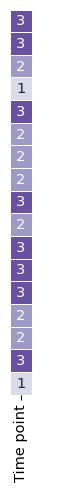

In [16]:
f, ax = plt.subplots (figsize = (0.4,5))
cmap = sns.color_palette("Purples", 3) 
sns.heatmap(ibd_matrix_sorted2.loc[:,["Time point"]],  
            linewidth=.5,  yticklabels = "", annot = True, 
            annot_kws={'size': 10.5}, cbar=False, cmap = cmap)
plt.xticks(rotation=90, size = 10.5)
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.7, box.height])
legend_ax = f.add_axes([.7, .5, 1, .1])
legend_ax.axis('off')
    
plt.savefig("./Figures/MILO_Fig6b_4.pdf", bbox_inches = "tight", dpi = 300)

plt.show()

In [17]:
ibd_matrix_sorted2 ['Disease status'] = 1
ibd_matrix_sorted2.loc [[name.split ("_")[0] == 'L' for name in ibd_matrix_sorted2['new_names']], 
                        'Disease status'] = 2
ibd_matrix_sorted2.loc [[name.split ("_")[0] == 'C' for name in ibd_matrix_sorted2['new_names']], 
                        'Disease status'] = 3
ibd_matrix_sorted2 ['Disease status'] = ibd_matrix_sorted2 ['Disease status'].astype("int")

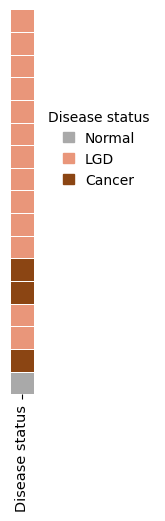

In [18]:
import matplotlib.patches as mpatches
f, ax = plt.subplots (figsize = (0.45,5))
cmap = sns.color_palette("Purples", 3) 
cmap = ['darkgrey', 'darksalmon', 'saddlebrown']
sns.heatmap(ibd_matrix_sorted2.loc[:,["Disease status"]],  
            linewidth=.5,  yticklabels = "", cbar=False, cmap = cmap)
plt.xticks(rotation=90, size = 10.5)
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.7, box.height])
legend_ax = f.add_axes([.7, .5, 1, .1])
legend_ax.axis('off')

colors = cmap
# add color map to legend
patches = [mpatches.Patch(facecolor=c, edgecolor=c) for c in colors]
legend = legend_ax.legend(patches,
    ['Normal','LGD','Cancer'],
    handlelength=0.8, loc='lower left', frameon = False, title = "Disease status")
for t in legend.get_texts():
    t.set_ha("left")
    
plt.savefig("./Figures/MILO_Fig6b_1.pdf", bbox_inches = "tight", dpi = 300)

plt.show()

In [19]:
ibd_matrix_sorted2['MILO_prediction'] = 0
ibd_matrix_sorted2.loc[ibd_matrix_sorted2['Prob(MSI)'] <= 0.5 , 'MILO_prediction'] = -1
ibd_matrix_sorted2.loc[ibd_matrix_sorted2['Prob(MSI)'] > 0.75, 'MILO_prediction'] = 1
ibd_matrix_sorted2 ['MILO_prediction'] = ibd_matrix_sorted2 ['MILO_prediction'].astype ("int")

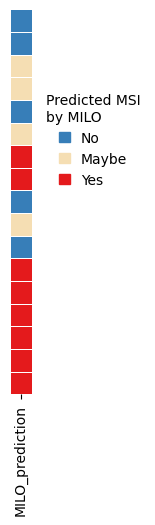

In [20]:
f, ax = plt.subplots (figsize = (0.4, 5))
#cmap = sns.color_palette("Set3") [4:7] 
cmap = [sns.color_palette("Set1")[1], 'wheat', sns.color_palette("Set1")[0]]
hm = sns.heatmap(ibd_matrix_sorted2.loc[:,["MILO_prediction"]], linewidth=.5,  
                 yticklabels = "", cbar=False, cmap = cmap)
plt.xticks(rotation=90)
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.7, box.height])
legend_ax = f.add_axes([.7, .5, 1, .1])
legend_ax.axis('off')

colors = cmap #plt.cm.Pastel2(np.linspace(0, 1, len(value_to_int)))
# add color map to legend
patches = [mpatches.Patch(facecolor=c, edgecolor=c) for c in colors]
legend = legend_ax.legend(patches,
    ['No','Maybe','Yes'],
    handlelength=0.8, loc='lower left', frameon = False, title = "Predicted MSI\nby MILO")
for t in legend.get_texts():
    t.set_ha("left")
plt.savefig("./Figures/MILO_Fig6b_2.pdf", bbox_inches = "tight", dpi = 300)
plt.show()

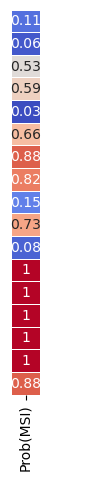

In [21]:
f, ax = plt.subplots (figsize = (0.55, 5))
cmap = sns.cubehelix_palette(light=1, as_cmap=True)

hm = sns.heatmap(ibd_matrix_sorted2.loc[:,["Prob(MSI)"]], 
                 linewidth=.5,  yticklabels = "", cbar = False, cmap = 'coolwarm',
                annot=True, annot_kws={'size': 10})
plt.xticks(rotation=90)
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.7, box.height])
legend_ax = f.add_axes([.7, .5, 1, .1])
legend_ax.axis('off')
plt.savefig("./Figures/MILO_Fig6b_3.pdf", bbox_inches = "tight", dpi = 300)
plt.show()

## Apply MILO to extract noise

In [22]:
## Provide cohort specfic noise pattern to MILO for noise correction
df1, df2 = MILO("./Data/IBD_Patient_2429_83c_indels.csv", 'FFPE', 
                NoiseCorrection = True,
               NoisePattern_ffpe = noise_profile_from_cohort)

In [23]:
samples_clade1 = ['B12_2429-TP2-P3A-B', 'XB6_2429-TP2-P3C-A']
df2['clade'] = 'clade 2'
df2.loc[[s in samples_clade1 for s in df2.index], 'clade'] = 'clade 1'

In [24]:
df2_norm = df2.loc[df2['clade'] == 'clade 2', :].copy()
df2_norm.iloc[:,:83] = (df2.iloc[:,:83].T/df2.iloc[:,:83].T.sum()).T

In [25]:
s_tp = {}
for s in ['ZD6_2429-TP1-P3D-B']:
    s_tp[s] = 'Time point 1'
for s in ['XF1_2429-TP2-P3B-B', 'F3_2429-TP2-P3B-A']:
    s_tp[s] = 'Time point 2'
for s in ['XC6_2429-TPF-2429-C1B','XC7_2429-TPF-2429-C1C', 'XC5_2429-TPF-2429-C1A']:
    s_tp[s] = 'Time point 3'

In [26]:
df2_norm['time point'] = [s_tp.get(s) for s in df2_norm.index.values]
mean_msi_profiles = df2_norm.drop (['MILO_prediction', 
                                    'clade'], axis = 1).groupby('time point').mean()

./Figures/MILO_Fig6cc.pdf


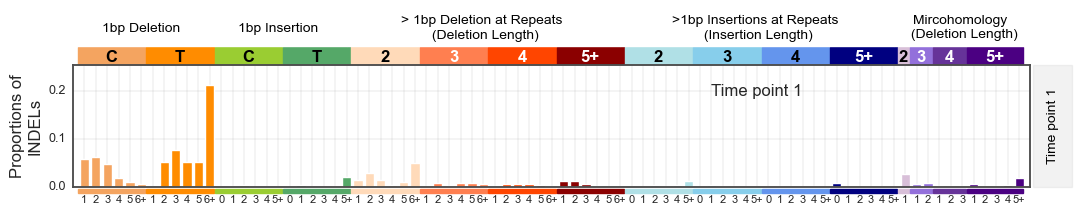

./Figures/MILO_Fig6cd.pdf


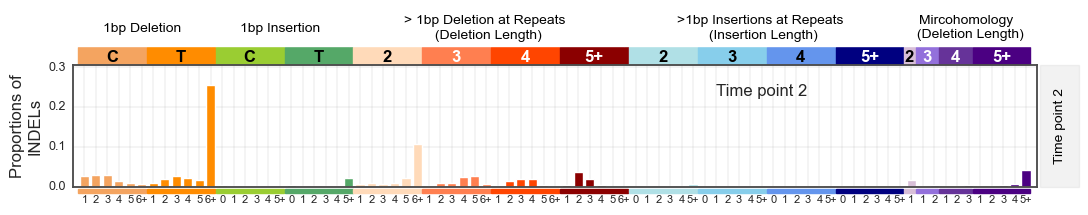

./Figures/MILO_Fig6ce.pdf


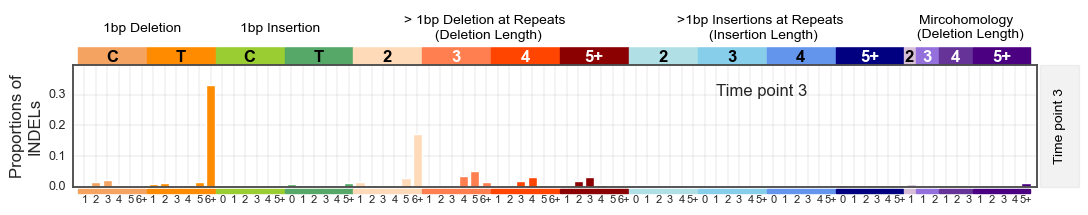

In [27]:
findex = ['c', 'd', 'e']
for i, tp in enumerate(mean_msi_profiles.index):
    print ("./Figures/MILO_Fig6c" + findex [i] + ".pdf")
    ID83_plot(mean_msi_profiles.loc[tp, :][:83], name = tp, norm = True,
              label = 'Noise corrected')

## Long deletion intensities

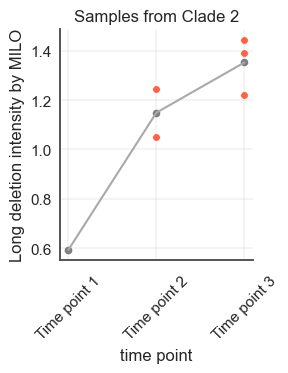

In [28]:
x = df2_norm.loc[:, ['long_del_intensity', 'time point']].groupby('time point').mean().index.values
y = df2_norm.loc[:, ['long_del_intensity', 
                 'time point']].groupby('time point').mean()['long_del_intensity'].values

df2_norm_sorted = df2_norm.sort_values('time point')

f, ax = plt.subplots(figsize = (2.5, 3))
sns.scatterplot (x = 'time point', y = 'long_del_intensity', 
                 data = df2_norm_sorted, color = "tomato", 
                 s = 30)
plt.xticks (rotation = 45)

plt.scatter (x, y, color = "grey" , s = 20)
plt.plot(x, y, color = "darkgrey")

sns.despine()

plt.title("Samples from Clade 2")
plt.ylabel ("Long deletion intensity by MILO")
plt.savefig("Figures/MILO_fig6d.pdf", bbox_inches = "tight", dpi = 300)
plt.show()